# Notebook 01 – EDA & Preprocessing cho baseline sparse

Mục tiêu của notebook:

1. Khôi phục và chuẩn hóa nhãn MITRE ATT&CK.
2. Giữ đồng thời nhãn chính xác và nhãn parent.
3. Chuẩn hóa IOC bằng token có ý nghĩa, không xóa từ kỹ thuật quan trọng.
4. Hợp nhất các bản ghi trùng nội dung để tránh leakage giữa các tập.
5. Lưu dữ liệu trung gian; vocabulary cuối cùng chỉ được chọn từ tập train ở Notebook 02.


In [38]:
import json
import random
import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'Dataset' / 'raw' / 'Attack_Dataset.csv'
DATA_OUT = PROJECT_ROOT / 'Dataset' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results'
DATA_OUT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Raw data    :', DATA_RAW)


Project root: D:\Truong\FPT\SUMMER2026\AIC211\CTI_ATT&CK\attack-classification
Raw data    : D:\Truong\FPT\SUMMER2026\AIC211\CTI_ATT&CK\attack-classification\Dataset\raw\Attack_Dataset.csv


## 1. Đọc dữ liệu và kiểm tra schema


In [39]:
df_raw = pd.read_csv(DATA_RAW)
df_raw.columns = [c.strip() for c in df_raw.columns]

print('Raw shape:', df_raw.shape)
print('\nNull counts:')
print(df_raw.isna().sum().sort_values(ascending=False).head(10))
display(df_raw.head(3))


Raw shape: (14133, 16)

Null counts:
Unnamed: 15         14087
Source                160
MITRE Technique        24
Vulnerability          18
Tools Used             14
Target Type             4
Detection Method        4
Impact                  3
Tags                    3
Solution                3
dtype: int64


,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),"A login form fails to validate or sanitize input, allowing attackers to log in as admin without knowing the password.","Browser, Burp Suite, SQLMap","1. Reconnaissance: Find a login form on the website (e.g., username and password fields). 2. Test for Injection: Ent...","Web Login Portals (e.g., banking, admin dashboards, e-commerce)",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-Facing App)","Full account takeover, data theft, privilege escalation","Web server logs, anomaly detection (e.g., logins without passwords), WAF alerts","Use prepared statements, Sanitize inputs, Limit login attempts, Use CAPTCHA, Enable MFA","SQLi, Authentication Bypass, Web Security, OWASP Top 10","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,"This attack occurs when a hacker uses the SQL ""UNION"" operator to combine results from a malicious query with a legi...","SQLMap, Burp Suite, Havij, Browser Developer Tools","1. Identify User Input Points: Attacker finds a search bar, login form, or URL that interacts with the database. 2. ...","Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQL queries to be altered,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeover, Unauthorized database access",Web Application Firewalls (WAF)Log AnalysisInput Sanitization LogsSQL Error Monitoring,Use parameterized queries (Prepared Statements)Sanitize all user inputsDisable detailed SQL error messagesApply leas...,#SQLInjection #WebSecurity #UnionAttack #OWASPTop10 #InjectionFlaws,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web Security Academy",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentionally triggers database errors to extract information. These errors ofte...,"SQLMap, Burp Suite, Manual Browser Testing, Havij","1. Identify Input Points:Attacker finds a field like login, search, or URL parameter that interacts with a database....","Web Applications, Login Forms, URL Parameters, Admin Panels",Error message exposure due to lack of input validation and improper database handling,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exposure, Entry point for further attacks, Sensitive data leakage",Review and monitor error logsEnable generic error pagesMonitor for unusual user inputsUse WAF to detect SQL errors,Turn off detailed error messages in productionUse parameterized queriesInput validation and sanitizationRegular vuln...,#SQLInjection #ErrorLeakage #WebAppSecurity #OWASPTop10 #DatabaseSecurity,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web Security Academy",NaN


## 2. Khôi phục nhãn và roll-up sub-technique về parent


In [40]:
MITRE_PATTERN = re.compile(r'\bT\d{4}(?:\.\d{3})?\b', flags=re.IGNORECASE)
RECOVERY_COLUMNS = ['MITRE Technique', 'Impact', 'Detection Method', 'Unnamed: 15']


def extract_mitre_codes(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    return [x.upper() for x in MITRE_PATTERN.findall(str(value))]


def recover_row_labels(row):
    '''Union các cột có thể chứa nhãn do CSV bị lệch; không quét text đầu vào.'''
    labels = set()
    for column in RECOVERY_COLUMNS:
        if column in row.index:
            labels.update(extract_mitre_codes(row[column]))
    return sorted(labels)


def parent_technique(code):
    '''T1059.001 -> T1059; nhãn đã là parent được giữ nguyên.'''
    return code.split('.', maxsplit=1)[0]


df = df_raw.copy()
df['labels_exact'] = df.apply(recover_row_labels, axis=1)
df = df[df['labels_exact'].map(bool)].copy()
df['labels_parent'] = df['labels_exact'].apply(
    lambda labels: sorted({parent_technique(x) for x in labels})
)

exact_counts = Counter(x for labels in df['labels_exact'] for x in labels)
parent_counts = Counter(x for labels in df['labels_parent'] for x in labels)

print('Rows có nhãn         :', len(df))
print('Unique exact labels  :', len(exact_counts))
print('Unique parent labels :', len(parent_counts))
print('Cardinality exact    :', round(df['labels_exact'].map(len).mean(), 3))
print('Cardinality parent   :', round(df['labels_parent'].map(len).mean(), 3))


Rows có nhãn         : 14070
Unique exact labels  : 773
Unique parent labels : 376
Cardinality exact    : 1.086
Cardinality parent   : 1.085


> Lưu ý: cắt hậu tố là bước chuẩn hóa cục bộ. Trước khi production cần đối chiếu các mã với ATT&CK STIX đã pin version để loại mã deprecated/không thuộc domain mong muốn.


## 3. Ghép trường văn bản đúng với dữ liệu có sẵn khi inference


In [41]:
TEXT_COLUMNS = ['Title', 'Scenario Description', 'Attack Steps', 'Tools Used']

for column in TEXT_COLUMNS:
    if column not in df.columns:
        df[column] = ''


def combine_text_fields(row):
    parts = []
    for column in TEXT_COLUMNS:
        value = row.get(column, '')
        if pd.notna(value) and str(value).strip():
            parts.append(str(value).strip())
    return '. '.join(parts)


df['combined_text'] = df.apply(combine_text_fields, axis=1)
print(df['combined_text'].iloc[0][:600])


Authentication Bypass via SQL Injection. A login form fails to validate or sanitize input, allowing attackers to log in as admin without knowing the password.. 1. Reconnaissance: Find a login form on the website (e.g., username and password fields). 2. Test for Injection: Enter a simple payload like ' OR '1'='1 in the username or password field. 3. Analyze Response: If the login succeeds or error message changes, it may be vulnerable. 4. Craft Exploit: Use payloads like: Username: ' OR '1'='1' --  Password: anything. 5. Bypass Authentication: The SQL query behind the scenes becomes: SELECT * F


## 4. Cyber-IOC masking và làm sạch nhẹ


In [42]:
# Token chỉ gồm chữ/số/_ để cả word và character TF-IDF giữ được ổn định.
NER_PATTERNS = [
    (r'\bCVE-\d{4}-\d{4,7}\b', ' ioc_cve '),
    (r'\b(?:\d{1,3}\.){3}\d{1,3}(?:/\d{1,2})?\b', ' ioc_ip '),
    (r'\b(?:[0-9a-f]{1,4}:){3,7}[0-9a-f]{1,4}\b', ' ioc_ip '),
    (r'\b[0-9a-f]{32}\b|\b[0-9a-f]{40}\b|\b[0-9a-f]{64}\b', ' ioc_hash '),
    (r'https?://[^\s"\']+', ' ioc_url '),
    (r'\b[\w.+-]+@[\w-]+\.[a-z]{2,}\b', ' ioc_email '),
    (r'[a-z]:\\(?:[^\\\s]+\\)*[^\\\s]+', ' ioc_path '),
    (r'(?<!\w)/(?:etc|home|var|usr|tmp|bin|sbin|opt|proc|dev|sys)(?:/[^\s,;]+)+', ' ioc_path '),
    (r'\bports?\s*(?:number\s*)?\d{1,5}\b|:\d{2,5}\b', ' ioc_port '),
]


def mask_entities(text):
    text = str(text)
    for pattern, replacement in NER_PATTERNS:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text


def clean_text(text):
    '''Làm sạch nhẹ: giữ command, filename và từ hành vi; không dùng stopword/stemming.'''
    text = unicodedata.normalize('NFKC', str(text)).lower()
    text = mask_entities(text)
    # Giữ _, -, ., /, \\ và : vì hữu ích cho command/path/extension và char n-gram.
    text = re.sub(r'[^a-z0-9_\-./\\:\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['text_clean'] = df['combined_text'].apply(clean_text)

probe = clean_text('CVE-2021-44228 used PowerShell at 10.0.0.1:443 without authentication.')
assert 'ioc_cve' in probe and 'ioc_ip' in probe and 'without' in probe
print('Preprocessing probe:', probe)
print('\nSample cleaned text:', df['text_clean'].iloc[0][:500])


Preprocessing probe: ioc_cve used powershell at ioc_ip ioc_port without authentication.

Sample cleaned text: authentication bypass via sql injection. a login form fails to validate or sanitize input allowing attackers to log in as admin without knowing the password.. 1. reconnaissance: find a login form on the website e.g. username and password fields . 2. test for injection: enter a simple payload like or 1 1 in the username or password field. 3. analyze response: if the login succeeds or error message changes it may be vulnerable. 4. craft exploit: use payloads like: username: or 1 1 -- password: any


## 5. Hợp nhất exact duplicates để chống train/test leakage


In [43]:
before = len(df)


def union_lists(series):
    return sorted({item for values in series for item in values})


# Nếu cùng text nhưng khác nhãn, hợp nhất nhãn thay vì âm thầm bỏ một annotation.
aggregations = {
    'ID': 'first',
    'Category': 'first',
    'Attack Type': 'first',
    'combined_text': 'first',
    'labels_exact': union_lists,
    'labels_parent': union_lists,
}
df = (
    df.groupby('text_clean', as_index=False, sort=False)
      .agg(aggregations)
      .reset_index(drop=True)
)

print('Rows trước dedupe:', before)
print('Rows sau dedupe  :', len(df))
print('Rows đã hợp nhất :', before - len(df))
assert df['text_clean'].is_unique


Rows trước dedupe: 14070
Rows sau dedupe  : 13829
Rows đã hợp nhất : 241


## 6. EDA phân bố parent label


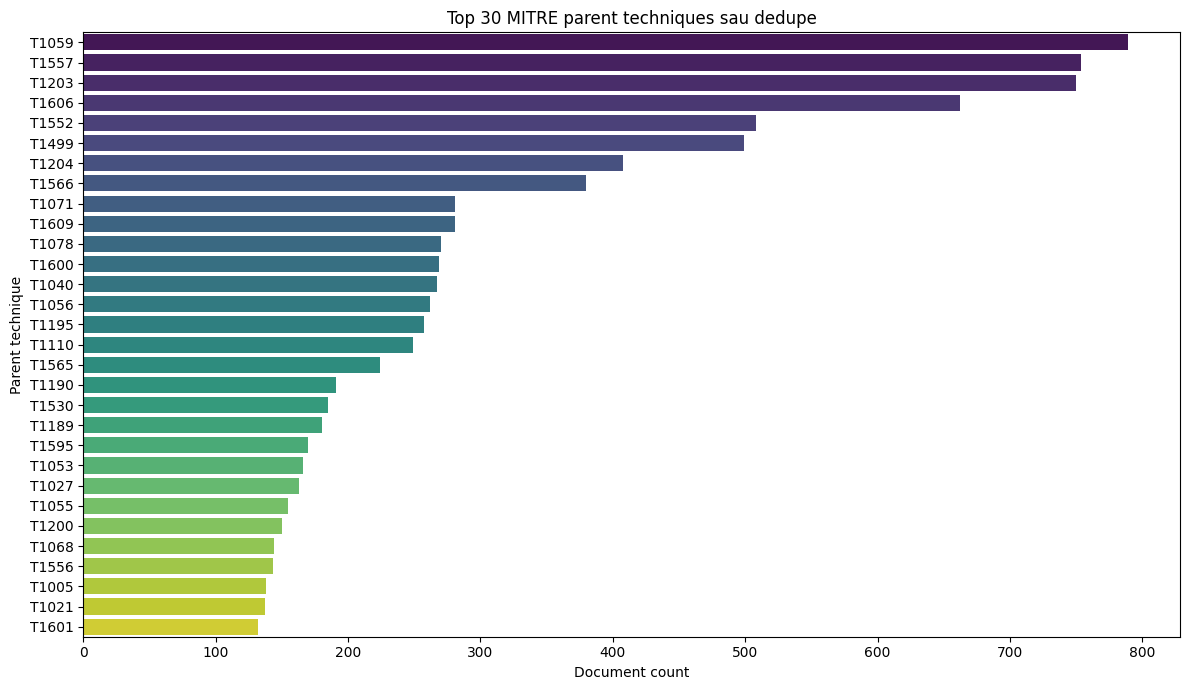

Parent support < 10: 215
Parent support < 20: 263
Median support     : 7.5


In [44]:
parent_counts = Counter(x for labels in df['labels_parent'] for x in labels)
top_parent = pd.Series(parent_counts).sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_parent.values, y=top_parent.index, ax=ax, palette='viridis')
ax.set_title('Top 30 MITRE parent techniques sau dedupe')
ax.set_xlabel('Document count')
ax.set_ylabel('Parent technique')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'parent_label_distribution.png', dpi=150)
plt.show()

supports = np.array(list(parent_counts.values()))
print('Parent support < 10:', int((supports < 10).sum()))
print('Parent support < 20:', int((supports < 20).sum()))
print('Median support     :', float(np.median(supports)))


## 7. Lưu dataset trung gian và cấu hình preprocessing


In [45]:
df_save = df[
    ['ID', 'Category', 'Attack Type', 'combined_text', 'text_clean',
     'labels_exact', 'labels_parent']
].copy()
df_save['labels_exact_str'] = df_save['labels_exact'].apply(lambda x: '|'.join(x))
df_save['labels_parent_str'] = df_save['labels_parent'].apply(lambda x: '|'.join(x))
df_save.drop(columns=['labels_exact', 'labels_parent'], inplace=True)

out_csv = DATA_OUT / 'dataset_processed.csv'
df_save.to_csv(out_csv, index=False)

preprocessing_config = {
    'version': 2,
    'label_mode': 'all_subtechniques_rolled_to_parent',
    'text_columns': TEXT_COLUMNS,
    'normalization': 'NFKC_lower_light_cleaning',
    'stopword_removal': False,
    'stemming': False,
    'seed': SEED,
}
with open(DATA_OUT / 'preprocessing_config.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_config, f, indent=2, ensure_ascii=False)

print('Saved:', out_csv, df_save.shape)
print('Saved:', DATA_OUT / 'preprocessing_config.json')
print('\nNotebook 02 sẽ split trước, rồi chọn vocabulary nhãn bằng support của TRAIN.')


Saved: D:\Truong\FPT\SUMMER2026\AIC211\CTI_ATT&CK\attack-classification\Dataset\processed\dataset_processed.csv (13829, 7)
Saved: D:\Truong\FPT\SUMMER2026\AIC211\CTI_ATT&CK\attack-classification\Dataset\processed\preprocessing_config.json

Notebook 02 sẽ split trước, rồi chọn vocabulary nhãn bằng support của TRAIN.
